In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import math
import re

In [3]:
import Xm

In [4]:
#xm=Xm.Xm(XmlFile='../testdata/FW.XML') # "C:\3S\Modelle\MVV_FW.XML"
xm=Xm.Xm(XmlFile=r'C:\3S\Modelle\MVV_FW.XML')

=== LFKT ===

In [5]:
xm.vLFKT.head()

,NAME,BESCHREIBUNG,LF,LF_min,LF_max,INTPOL,ZEITOPTION,pk
0,LfTh,Beschreibung Tabelle,1,1,1,0,0,4843828177877341965
1,LFKT,Lastgang f(LFT),1,1,1,0,0,5416134108033797245


=== FWVB ===

In [6]:
xm.vFWVB.head()

,BESCHREIBUNG,IDREFERENZ,W0,LFK,TVL0,TRS0,LFKT,W,W_min,W_max,INDTR,TRSK,VTYP,IMBG,IRFV,pk,tk
0,0027000100081969,0027000100081969,28.3694,1,130,60,LfTh,28.3694,28.3694,28.3694,1,60,14,0,0,4611705704312427555,4611705704312427555
1,0027000100082399,0027000100082399,11.0988,1,130,60,LfTh,11.0988,11.0988,11.0988,1,60,14,0,0,4611716311966411404,4611716311966411404
2,00270001000aae9f,00270001000aae9f,10.1879,1,130,60,LfTh,10.1879,10.1879,10.1879,1,60,14,0,0,4611736166024041528,4611736166024041528
3,0027000100080d83,0027000100080d83,14.5338,1,130,60,LfTh,14.5338,14.5338,14.5338,1,60,14,0,0,4611782936366604697,4611782936366604697
4,002700010008004a,002700010008004a,27.2216,1,130,60,LfTh,27.2216,27.2216,27.2216,1,60,14,0,0,4611854962097939819,4611854962097939819


In [ ]:
#%matplotlib inline

In [16]:
plt.close('all')
plt.figure()
plt.subplot()

In [17]:
xm.vFWVB_Plt_Hist()

In [18]:
plt.title('xxx')

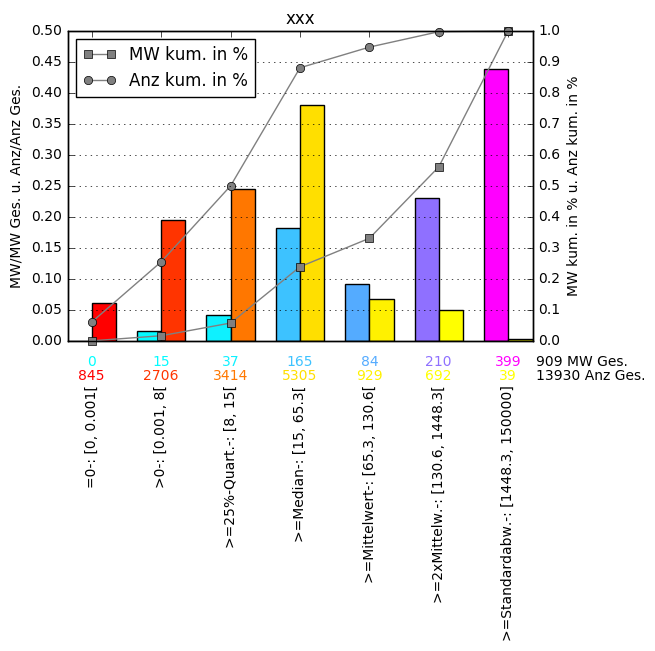

In [19]:
plt.show()

# xxxx

In [ ]:
xm.vVKNO.head(5)


In [ ]:
xm.vKNOT.head(5)

In [ ]:
xm.vKNOT[['NAME']].size

In [ ]:
xm.vKNOT[(xm.vKNOT['KTYP'].isin(['QKON']) & xm.vKNOT['QM_EIN'].astype(float)!=0) | xm.vKNOT['KTYP'].isin(['QVAR'])][[
                    'NAME'              
                   ,'CONT'
                   ,'CONT_VKNO' # vVKNO
                   ,'KTYP'
                   ,'LFAKT','QM_EIN','QVAR','QM','QM_min','QM_max'     
                   ,'KVR' 
                   ,'TE','TM'                   
    ]].sort_values(by=['CONT_VKNO','NAME'])

In [ ]:
xm.pRSLW.head()

In [ ]:
xm.dataFrames['NRCV'].columns

In [ ]:
vDPGR=pd.merge(xm.dataFrames['DPGR'],xm.dataFrames['DPGR_BZ'],left_on='pk',right_on='fk')

In [ ]:
vDPGR.columns

In [ ]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR IDs
       ,'pk_x', 'tk'
        # DPGR_BZ        
    ]]

In [ ]:
vDPGR.rename(columns={'pk_x':'pk'},inplace=True)

In [ ]:
vDPGR=pd.merge(vDPGR,xm.dataFrames['DPGR_ROWS'],left_on='pk',right_on='fk')

In [ ]:
vDPGR.columns

In [ ]:
vDPGR=vDPGR[[
        # DPGR
        'NAME'
        # DPGR_BZ   
        # DPGR_ROWS
       ,'OBJTYPE','NAME1','NAME2','NAME3','ATTRTYPE'
       ,'ADDEND','FACTOR','DEVIATION'
       ,'FLAGS','CLIENT_FLAGS'
       ,'DESCRIPTION','TITLE','UNIT' 
       ,'DATALENGTH', 'DATATYPE'
       ,'LOWER_LIMIT','UPPER_LIMIT'
       ,'OL3COMMAND','EPKZ'
        # DPGR IDs
       ,'pk_x', 'tk_x'  
       ,'fkOBJTYPE'
       # DPGR_ROWS IDs 
       ,'pk_y','tk_y'
    ]]

In [ ]:
cDct=dict(zip(vDPGR,vDPGR))

In [ ]:
vDPGR.rename(columns={'pk_x':'pk','tk':'tk','pk_y':'pkROWS','tk_y':'tkROWS'},inplace=True)

In [ ]:
xm.dataFrames['DPGR_ROWS'].columns

In [ ]:
vDPGR.head()

In [ ]:
pd.merge(vDPGR,xm.dataFrames[vDPGR.apply(lambda row: row.OBJTYPE, axis=1)],left_on='fkOBJTYPE',right_on='pk')

In [ ]:
xm.vKNOT.columns

In [ ]:
sorted(xm.dataFrames.keys())